In [51]:
%matplotlib inline

import numpy as np
from roboticstoolbox.robot.ERobot import ERobot, ERobot2
from roboticstoolbox.robot.Robot import Robot
from matplotlib import pyplot
from roboticstoolbox import DHRobot, RevoluteDH, RevoluteMDH
import roboticstoolbox as rtb
from spatialmath import SE3
import os

<p align="center">
    <img src="./src/robot_description/image.png" alt="robot">
</p>

In [52]:
class MyRobot(Robot):
    def __init__(self):
        current_dir = os.getcwd()
        urdf_path = os.path.join(current_dir, "src/robot_description/urdf/my-robot.xacro")
        
        links, name, urdf_string, urdf_filepath = ERobot.URDF_read(urdf_path)
        # for link in links:
        #     print(link)

        super().__init__(
            links,
            name=name.upper(),
            manufacturer="RRR Robotics",
            urdf_string=urdf_string,
            urdf_filepath=urdf_filepath,
        )

        self.qz = np.zeros(6)

        self.addconfiguration("qz", self.qz)


ERobot: ROBOT (by RRR Robotics), 3 joints (RRR), geometry
┌──────┬───────────────┬───────┬────────┬───────────────────────────────────────────┐
│ link │     link      │ joint │ parent │            ETS: parent to link            │
├──────┼───────────────┼───────┼────────┼───────────────────────────────────────────┤
│    0 │ link_0        │       │ BASE   │ SE3()                                     │
│    1 │ link_1        │     0 │ link_0 │ SE3(0, 0, 0.2) ⊕ Rz(q0)                   │
│    2 │ link_2        │     1 │ link_1 │ SE3(0, -0.12, 0; 0°, -90°, -90°) ⊕ Rz(q1) │
│    3 │ link_3        │     2 │ link_2 │ SE3(0.25, 0, 0.1) ⊕ Rz(q2)                │
│    4 │ @end_effector │       │ link_3 │ SE3(0.28, 0, 0; 90°, -0°, 90°)            │
└──────┴───────────────┴───────┴────────┴───────────────────────────────────────────┘

┌──────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2  │
├──────┼─────┼─────┼─────┤
│   qz │  0° │  0° │  0° │
└──────┴─────┴─────┴─────┘

SE3(0, 0, 0.2) ⊕ Rz(q0) ⊕ SE3(0

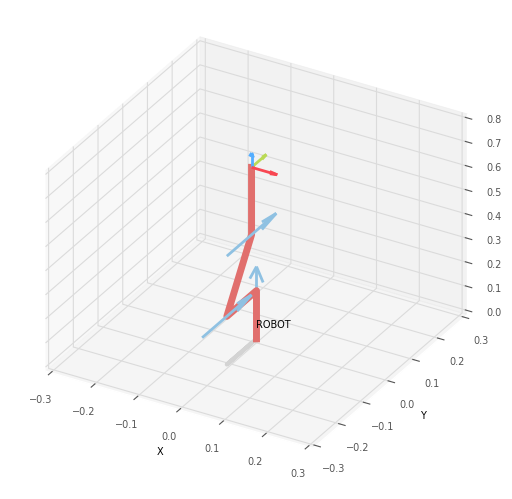

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [53]:
robot = MyRobot()
print(robot)
print(robot.ets())
print("\nForward kinematics at zero configuration:")
print(robot.fkine(robot.qz))
robot.plot([0,0,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])


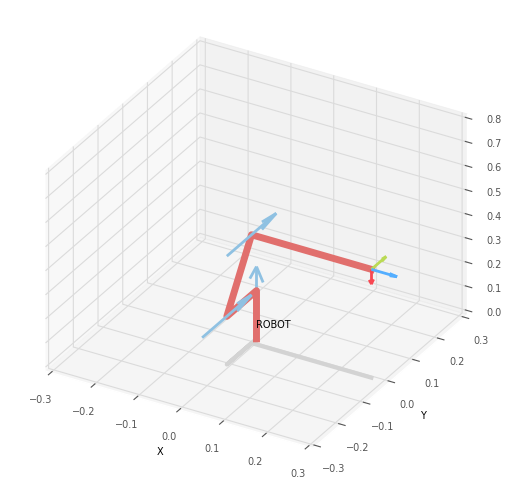

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [62]:
# tesing move joints at joint 3 at -90 degree
robot.qz = [0, 0, np.pi/2]
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

In [55]:
T = robot.fkine(robot.qz)
current_pos = T.t
target_pos = np.array([0.2, 0.3, 0.5])
# Compute position error
error = target_pos - current_pos
error_norm = np.linalg.norm(error)
print("Current Position:", current_pos)
print("Target Position:", target_pos)
print("Position Error:", error)
print("Error Norm:", error_norm)


Current Position: [ 0.27999987 -0.01999996  0.45000013]
Target Position: [0.2 0.3 0.5]
Position Error: [-0.07999987  0.31999996  0.04999987]
Error Norm: 0.3336164564722086


Arrived at the target position at iteration 241!


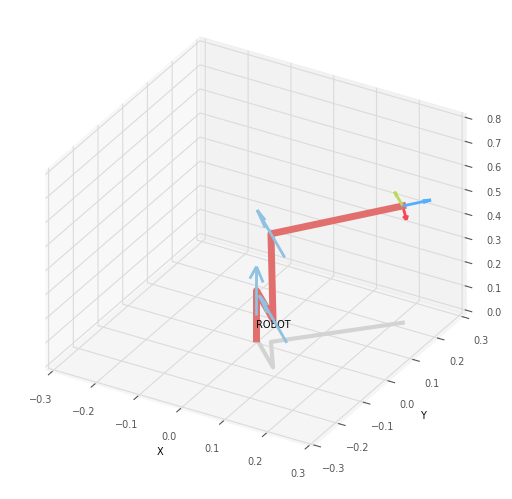

Total simulation time: 2.410s
Total iterations: 241
Final position: [0.22368854 0.20434765 0.4850442 ]
Target position: [0.2 0.3 0.5]
Final error: 0.099670


<Figure size 640x480 with 0 Axes>

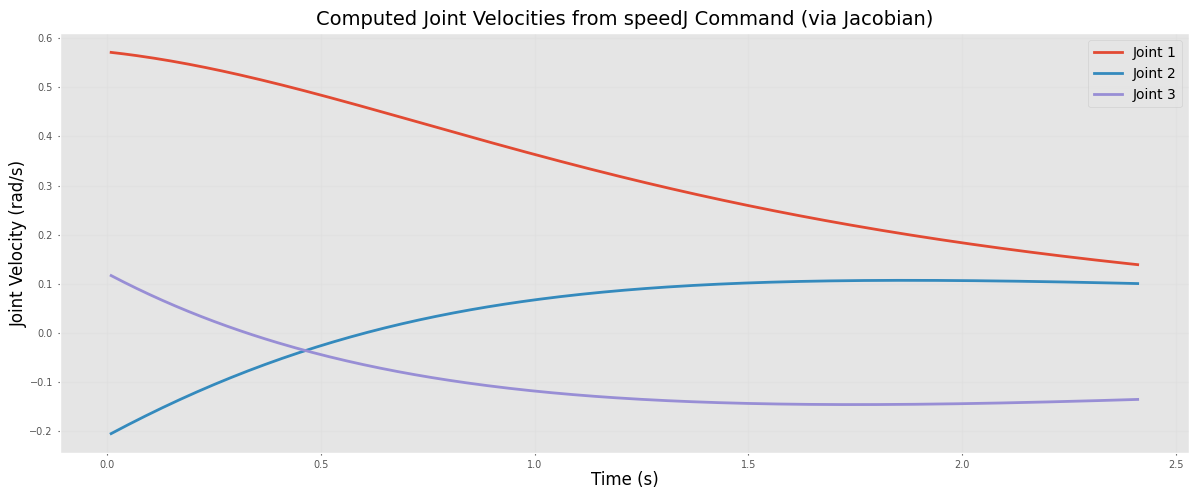

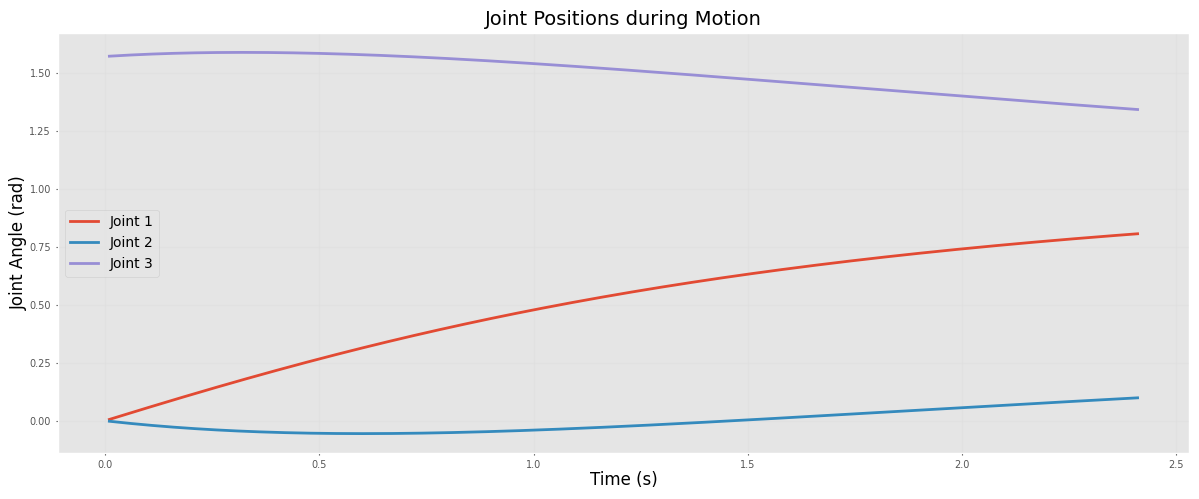

In [56]:
import matplotlib.pyplot as plt

arrived = False
dt = 0.01  # Fixed time step (simulation time, not real time)
computed_joint_velocities = []
joint_positions = []
time_stamps = []                 # Record the cumulative simulation time for each iteration
cumulative_time = 0.0            # Track total elapsed time
max_iterations = 10000           # Safety limit to prevent infinite loop
threshold = 0.1                  # Position error threshold for arrival
iteration = 0
while not arrived and iteration < max_iterations:
    T = robot.fkine(robot.qz)
    current_pos = T.t
    
    # Compute position error
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)
    
    if error_norm < threshold:
        arrived = True
        print(f"Arrived at the target position at iteration {iteration}!")
        break
    
    # Simple proportional controller for velocity
    Kp = 0.5
    v = Kp * error
    
    # Compute Jacobian at current configuration
    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]  # Position part only

    condJ = np.linalg.cond(J_pos)
    if condJ > 1e12:
        print(f"Warning: Jacobian is ill-conditioned (cond={condJ:.2e}) at iteration {iteration}.")
        break

    # Compute joint velocities using the position-only Jacobian
    qd = np.linalg.pinv(J_pos) @ v

    # Update joint angles
    robot.qz = robot.qz + qd * dt
    # Store data for plotting
    computed_joint_velocities.append(qd)
    joint_positions.append(robot.qz.copy())
    cumulative_time += dt
    time_stamps.append(cumulative_time)
    
    iteration += 1

if iteration >= max_iterations and not arrived:
    print("Reached maximum iterations without meeting the error threshold.")
    
# Convert the lists to numpy arrays for plotting
if computed_joint_velocities:
    computed_joint_velocities = np.array(computed_joint_velocities)
else:
    computed_joint_velocities = np.zeros((0, robot.n))
if joint_positions:
    joint_positions = np.array(joint_positions)
else:
    joint_positions = np.zeros((0, robot.n))
    
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])
print(f"Total simulation time: {cumulative_time:.3f}s")
print(f"Total iterations: {len(time_stamps)}")
print(f"Final position: {robot.fkine(robot.qz).t}")
print(f"Target position: {target_pos}")
print(f"Final error: {np.linalg.norm(target_pos - robot.fkine(robot.qz).t):.6f}")

# --- Plotting the Computed Joint Velocities ---
plt.figure(figsize=(12, 5))
if len(time_stamps) and computed_joint_velocities.size:
    num_joints = computed_joint_velocities.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, computed_joint_velocities[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint velocity data recorded', ha='center', va='center')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Joint Velocity (rad/s)", fontsize=12)
plt.title("Computed Joint Velocities from speedJ Command (via Jacobian)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plotting the Joint Positions ---
plt.figure(figsize=(12, 5))
if len(time_stamps) and joint_positions.size:
    num_joints = joint_positions.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, joint_positions[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint position data recorded', ha='center', va='center')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Joint Angle (rad)", fontsize=12)
plt.title("Joint Positions during Motion", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Joint limits (rad):
lower: [-3.14159 -3.14159 -3.14159]
upper: [3.14159 3.14159 3.14159]
Plotted 2000 workspace samples from joint Monte Carlo


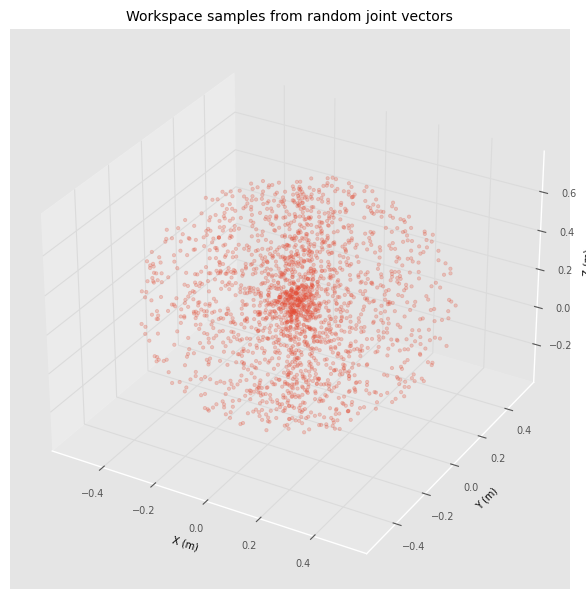

In [57]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Visualize workspace via joint-space Monte Carlo
workspace_samples = 2000

qlim = np.array(robot.qlim)
if qlim.shape[0] == 2:
    qlim = qlim.T
lower = qlim[:, 0]
upper = qlim[:, 1]
print('Joint limits (rad):')
print(f'lower: {qlim.T[0]}')
print(f'upper: {qlim.T[1]}')

workspace_positions = []
for _ in range(workspace_samples):
    rand = np.random.uniform(size=robot.n)
    q_random = lower + rand * (upper - lower)
    T = robot.fkine(q_random)
    workspace_positions.append(np.array(T.t).reshape(-1))

workspace_positions = np.array(workspace_positions)
print(f'Plotted {len(workspace_positions)} workspace samples from joint Monte Carlo')

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
if len(workspace_positions):
    ax.scatter(workspace_positions[:, 0], workspace_positions[:, 1], workspace_positions[:, 2], s=6, alpha=0.25)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Workspace samples from random joint vectors')
plt.tight_layout()
plt.show()


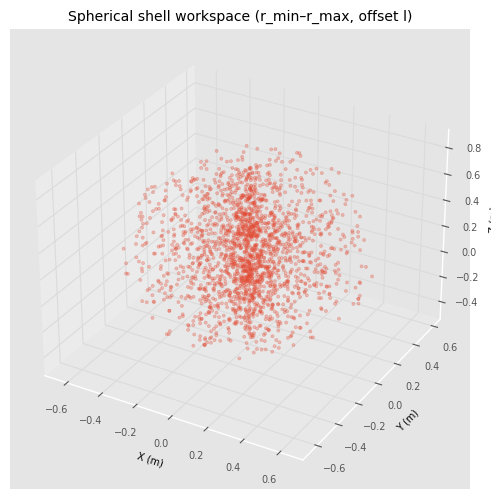

In [58]:
import numpy as np
import matplotlib.pyplot as plt

r_max = 0.12 + 0.25 + 0.28
r_min = 0.10
l = 0.2

# สุ่มจุดบนทรงเปลือก
num_points = 2000
phi = np.random.uniform(0, 2*np.pi, num_points)
theta = np.random.uniform(0, np.pi, num_points)
r = np.random.uniform(r_min, r_max, num_points)

x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = l + r * np.cos(theta)    # เลื่อนขึ้นสูง l


fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=5, alpha=0.3)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Spherical shell workspace (r_min–r_max, offset l)')
plt.tight_layout()
plt.show()


In [59]:
import matplotlib.pyplot as plt

r_max = 0.12 + 0.25 + 0.28
r_min = 0.10
l = 0.2
cond_threshold = 1e3
max_attempts = 10

position = None
q_solution = None
attempts = 0

while position is None and attempts < max_attempts:
    x = np.random.uniform(-r_max, r_max)
    y = np.random.uniform(-r_max, r_max)
    z = np.random.uniform(l - r_max, l + r_max)
    size_sq = x**2 + y**2 + (z - l)**2

    if not (r_min**2 < size_sq < r_max**2):
        attempts += 1
        continue

    T_target = SE3(x, y, z) @ SE3.Rx(np.pi/2)
    sol = robot.ikine_LM(T_target, mask=[1, 1, 1, 0, 0, 0])

    q_candidate = sol.q
    J = robot.jacob0(q_candidate)
    condJ = np.linalg.cond(J[:3, :])
    if condJ >= cond_threshold:
        print(f'Attempt {attempts}: condition number too high ({condJ:.2e}), retrying...')
        attempts += 1
        continue

    position = np.array([x, y, z])
    q_solution = q_candidate
    print(f'Found valid pose at attempt {attempts}')
    attempts += 1

if position is None:
    print(f'Failed to find a valid pose within {max_attempts} attempts')
else:
    radius = np.linalg.norm(position)
    print(f'Found pose after {attempts} attempts: {position}')
    print(f'Condition number: {np.linalg.cond(robot.jacob0(q_solution)[:3, :]):.2e}')
    print(f'Radius: {radius:.3f} m, Z: {position[2]:.3f} m')
    # robot.plot(q_solution, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])
    target_pos = position.copy()
    # T_solution = robot.fkine(q_solution)
    # target_tcp_pos = np.array(T_solution.t).reshape(-1)
    # print(f'Target TCP Position: {target_tcp_pos}')


Found valid pose at attempt 1
Found pose after 2 attempts: [ 0.27464542  0.16194688 -0.27038736]
Condition number: 2.95e+01
Radius: 0.418 m, Z: -0.270 m


Starting TCP position: [0.22368854 0.20434765 0.4850442 ]
Target position: [ 0.27464542  0.16194688 -0.27038736]
Reached maximum iterations without meeting the error threshold.


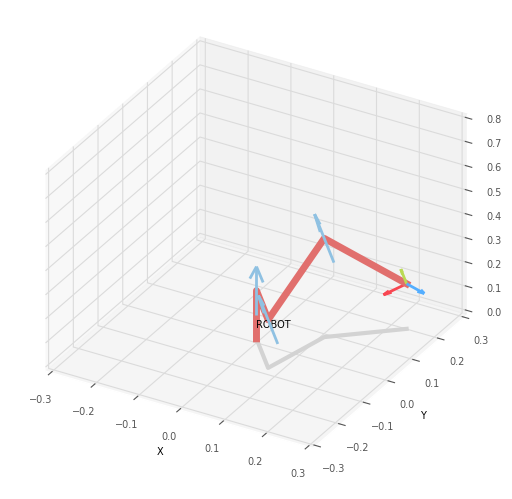

Total simulation time: 1.000s
Total iterations: 100
Final position: [0.24292474 0.18681178 0.18734896]
Final error: 0.459507
RMSE: 0.265297


<Figure size 640x480 with 0 Axes>

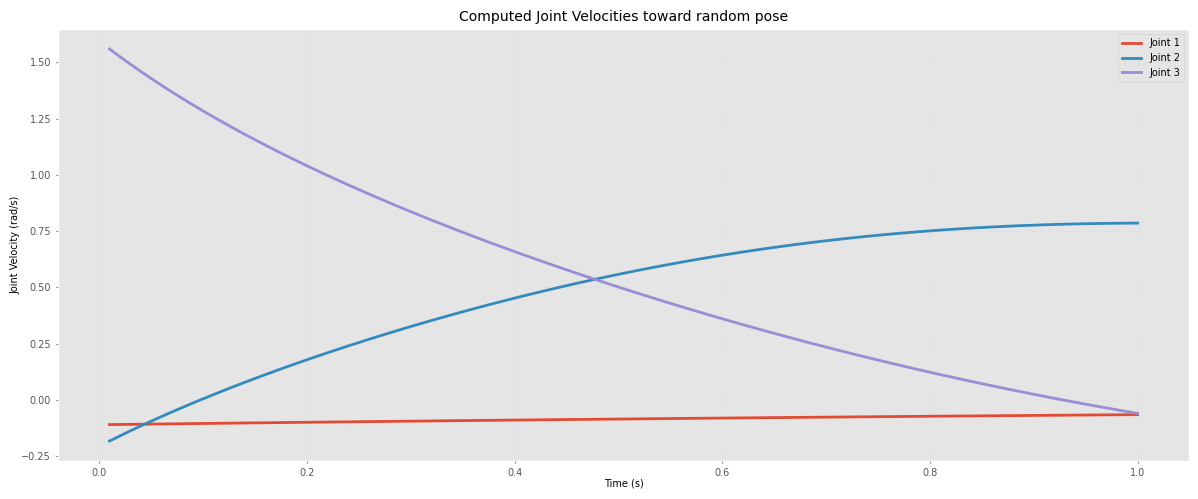

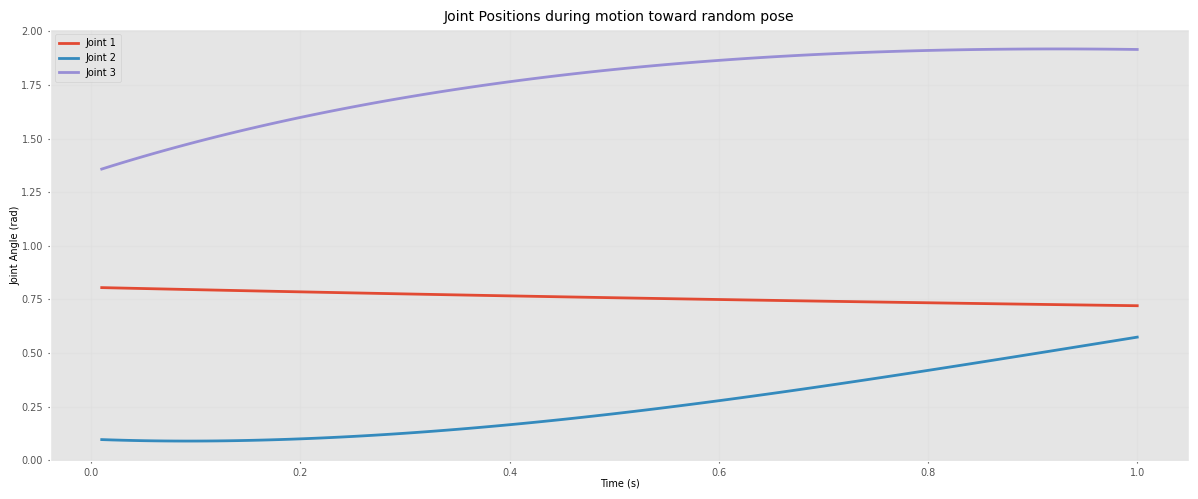

In [60]:
import matplotlib.pyplot as plt

if 'target_pos' not in globals():
    raise RuntimeError('Run the random pose sampling cell first to set target_pos')

arrived = False
dt = 0.01
computed_joint_velocities = []
joint_positions = []
time_stamps = []
cumulative_time = 0.0
max_iterations = 100
threshold = 0.01
iteration = 0

start_tcp = robot.fkine(robot.qz)
start_config = np.array(start_tcp.t).reshape(-1)
print(f'Starting TCP position: {start_config}')
print(f'Target position: {target_pos}')


while not arrived and iteration < max_iterations:
    T = robot.fkine(robot.qz)
    current_pos = T.t
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)

    if error_norm < threshold:
        arrived = True
        print(f"Arrived at the target position at iteration {iteration}!")
        break

    Kp = 0.5
    v = Kp * error

    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]
    condJ = np.linalg.cond(J_pos)
    if condJ > 1e12:
        print(f"Warning: Jacobian is ill-conditioned (cond={condJ:.2e}) at iteration {iteration}.")
        break

    qd = np.linalg.pinv(J_pos) @ v
    robot.qz = robot.qz + qd * dt

    computed_joint_velocities.append(qd)
    joint_positions.append(robot.qz.copy())
    cumulative_time += dt
    time_stamps.append(cumulative_time)

    iteration += 1

if iteration >= max_iterations and not arrived:
    print("Reached maximum iterations without meeting the error threshold.")

computed_joint_velocities = np.array(computed_joint_velocities) if computed_joint_velocities else np.zeros((0, robot.n))
joint_positions = np.array(joint_positions) if joint_positions else np.zeros((0, robot.n))

robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])
print(f"Total simulation time: {cumulative_time:.3f}s")
print(f"Total iterations: {len(time_stamps)}")
print(f"Final position: {robot.fkine(robot.qz).t}")
print(f"Final error: {np.linalg.norm(target_pos - robot.fkine(robot.qz).t):.6f}")
print(f"RMSE: {np.sqrt(np.mean((target_pos - robot.fkine(robot.qz).t)**2)):.6f}")

plt.figure(figsize=(12, 5))
if len(time_stamps) and computed_joint_velocities.size:
    num_joints = computed_joint_velocities.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, computed_joint_velocities[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint velocity data recorded', ha='center', va='center')
plt.xlabel("Time (s)")
plt.ylabel("Joint Velocity (rad/s)")
plt.title("Computed Joint Velocities toward random pose")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
if len(time_stamps) and joint_positions.size:
    num_joints = joint_positions.shape[1]
    for j in range(num_joints):
        plt.plot(time_stamps, joint_positions[:, j], label=f'Joint {j+1}', linewidth=2)
else:
    plt.text(0.5, 0.5, 'No joint position data recorded', ha='center', va='center')
plt.xlabel("Time (s)")
plt.ylabel("Joint Angle (rad)")
plt.title("Joint Positions during motion toward random pose")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
